In [ ]:
import pandas as pd

# Load the dataset
file_path = '/content/bank-full.csv'  # Replace with your file path
raw_data = pd.read_csv(file_path, sep=';')

# Preview the data
print("Dataset Preview:")
print(raw_data.head())

# Dataset Information
print("Dataset Info:")
print(raw_data.info())
output_file_path = 'formatted_bank_data.csv'
raw_data.to_csv(output_file_path, index=False)
print(f"Formatted data saved to {output_file_path}")



Dataset Preview:
   age           job  marital  education default  balance housing loan  \
0   58    management  married   tertiary      no     2143     yes   no   
1   44    technician   single  secondary      no       29     yes   no   
2   33  entrepreneur  married  secondary      no        2     yes  yes   
3   47   blue-collar  married    unknown      no     1506     yes   no   
4   33       unknown   single    unknown      no        1      no   no   

   contact  day month  duration  campaign  pdays  previous poutcome   y  
0  unknown    5   may       261         1     -1         0  unknown  no  
1  unknown    5   may       151         1     -1         0  unknown  no  
2  unknown    5   may        76         1     -1         0  unknown  no  
3  unknown    5   may        92         1     -1         0  unknown  no  
4  unknown    5   may       198         1     -1         0  unknown  no  
Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 45211 entries, 0 to 45210
Data

In [ ]:
# Remove unnecessary characters
raw_data = raw_data.replace('"', '', regex=True)

# Check for missing values
missing_values = raw_data.isnull().sum()
print("Missing Values:\n", missing_values)

# Drop rows with missing values (if any exist)
raw_data = raw_data.dropna()

print("Cleaned Dataset Preview:")
print(raw_data.head())


Missing Values:
 age          0
job          0
marital      0
education    0
default      0
balance      0
housing      0
loan         0
contact      0
day          0
month        0
duration     0
campaign     0
pdays        0
previous     0
poutcome     0
y            0
dtype: int64
Cleaned Dataset Preview:
   age           job  marital  education default  balance housing loan  \
0   58    management  married   tertiary      no     2143     yes   no   
1   44    technician   single  secondary      no       29     yes   no   
2   33  entrepreneur  married  secondary      no        2     yes  yes   
3   47   blue-collar  married    unknown      no     1506     yes   no   
4   33       unknown   single    unknown      no        1      no   no   

   contact  day month  duration  campaign  pdays  previous poutcome   y  
0  unknown    5   may       261         1     -1         0  unknown  no  
1  unknown    5   may       151         1     -1         0  unknown  no  
2  unknown    5   may  

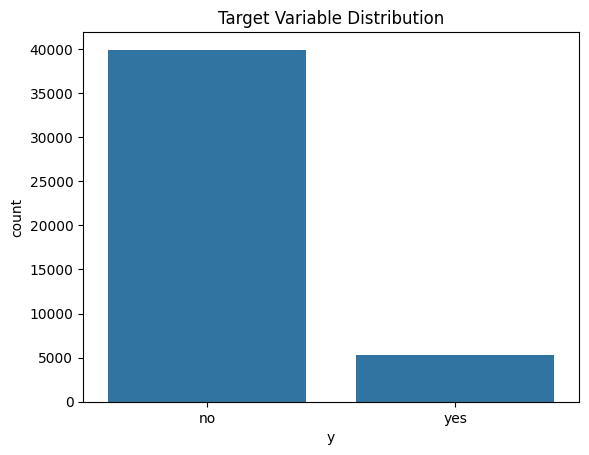

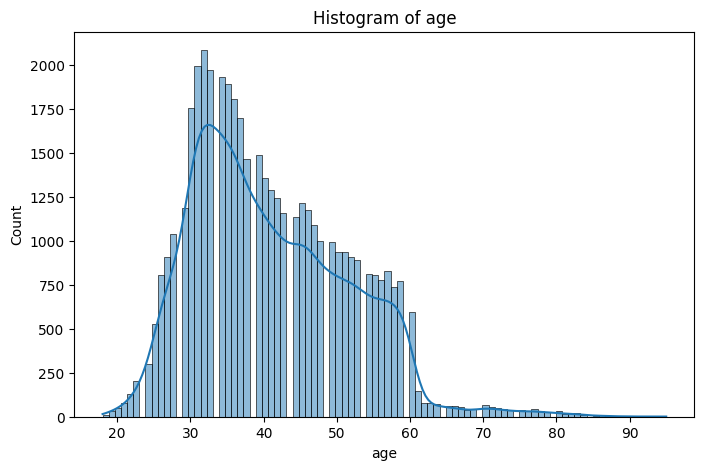

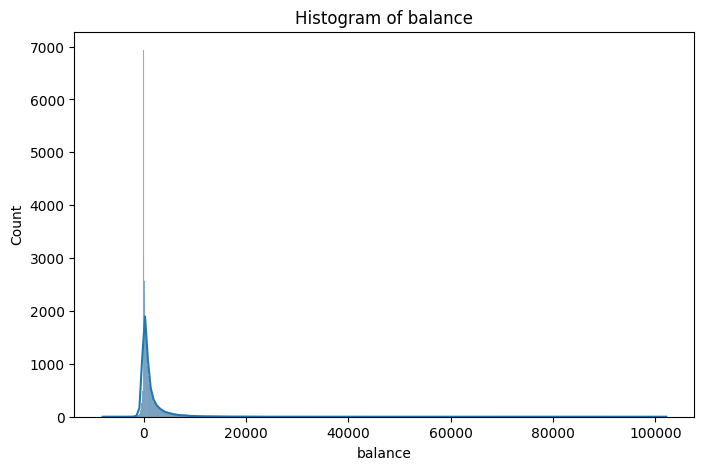

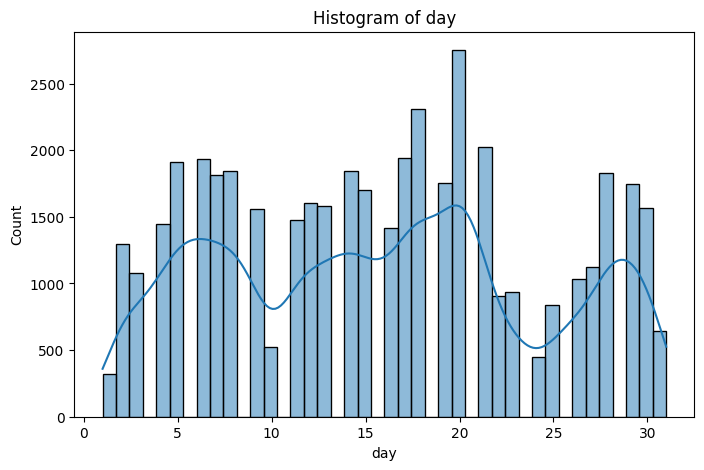

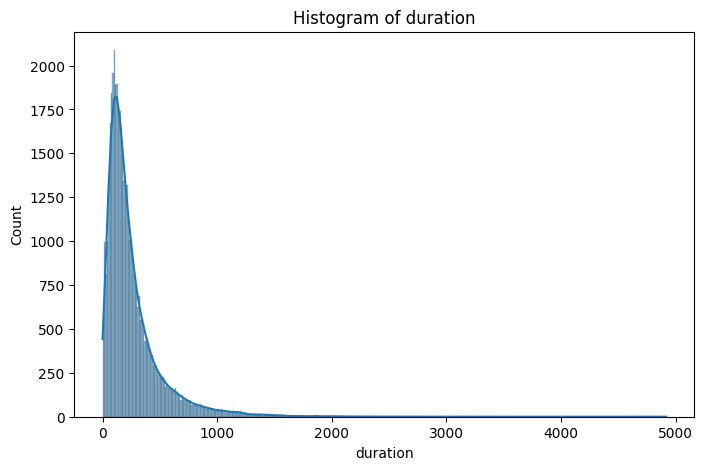

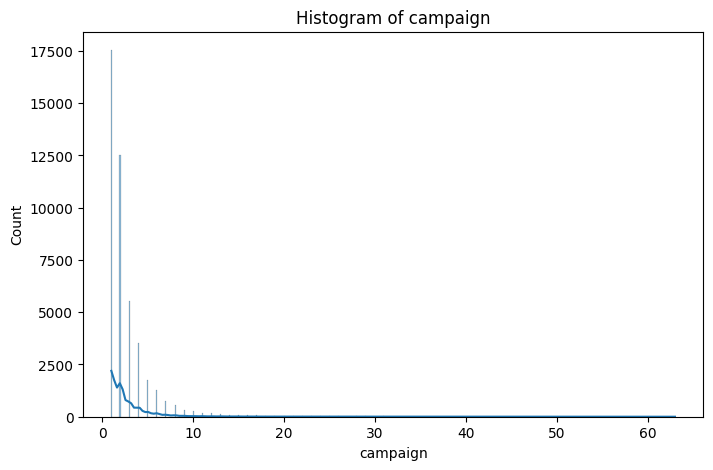

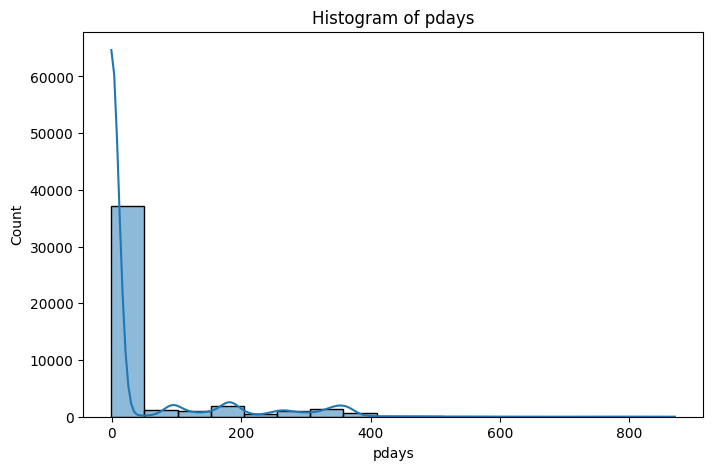

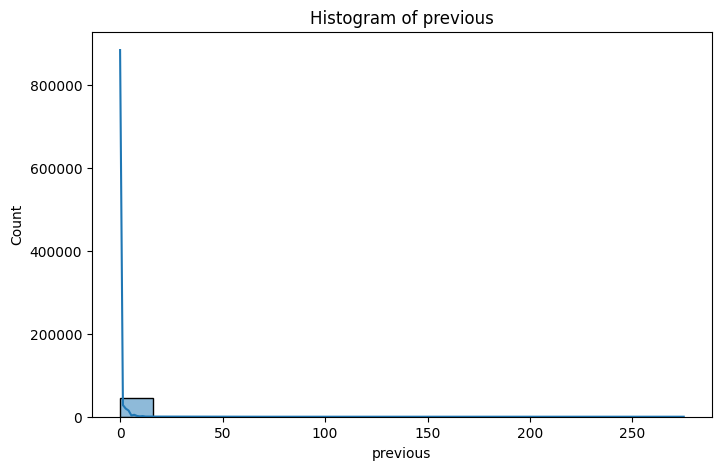

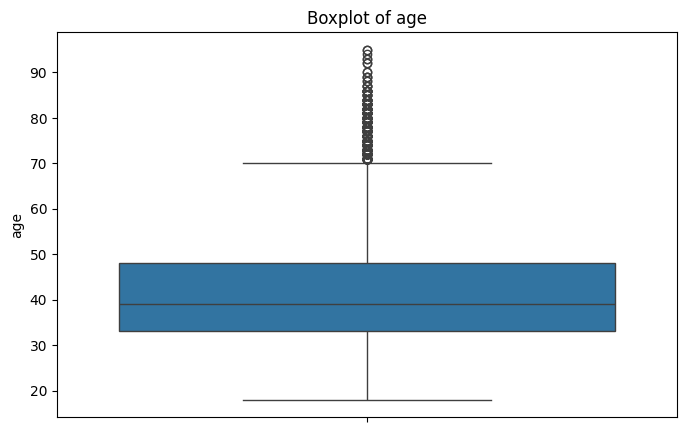

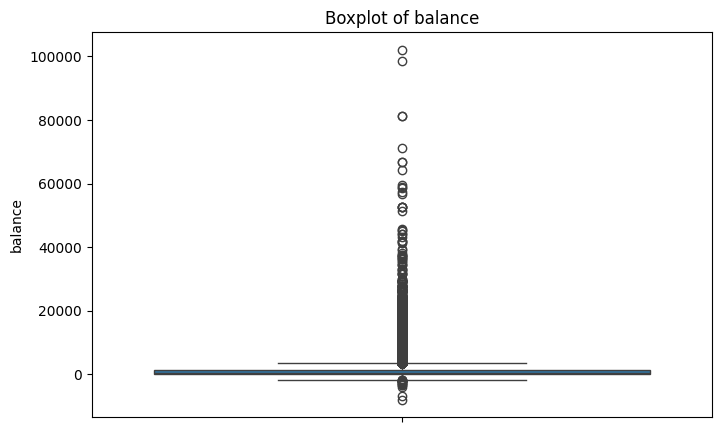

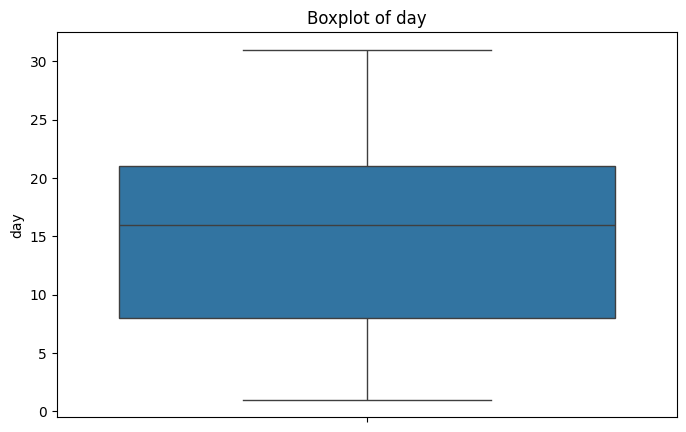

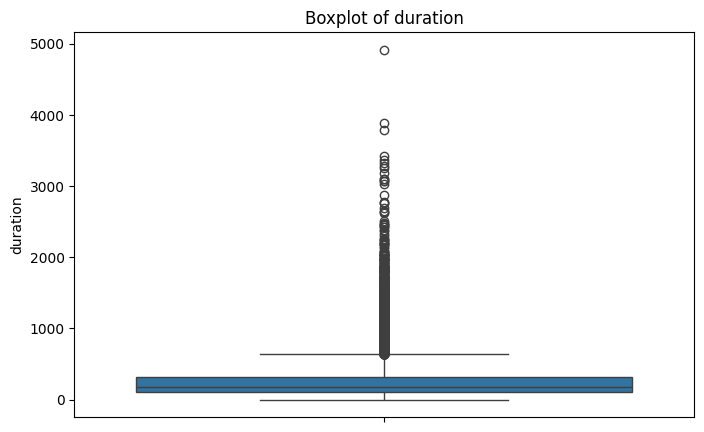

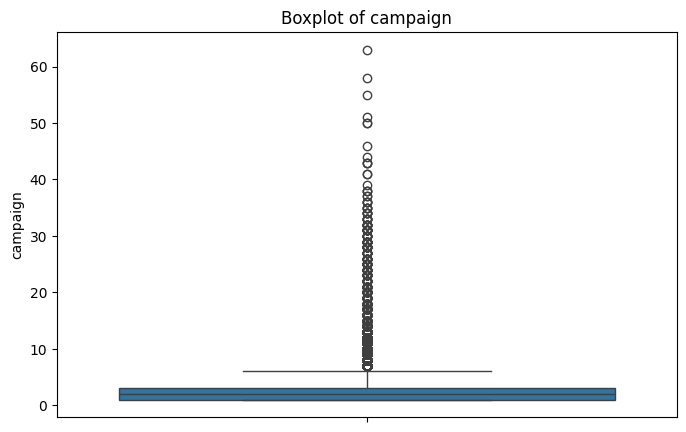

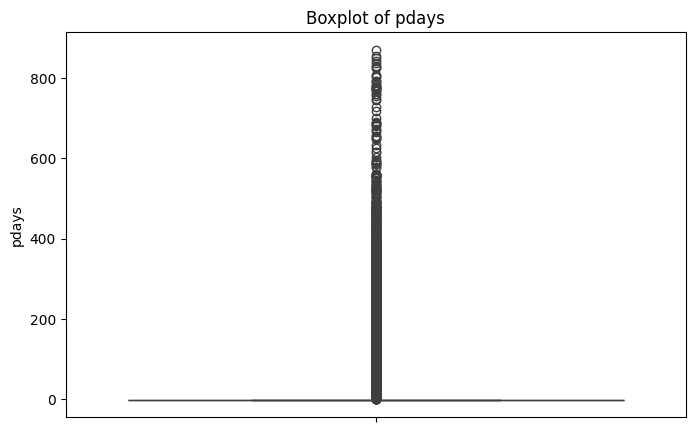

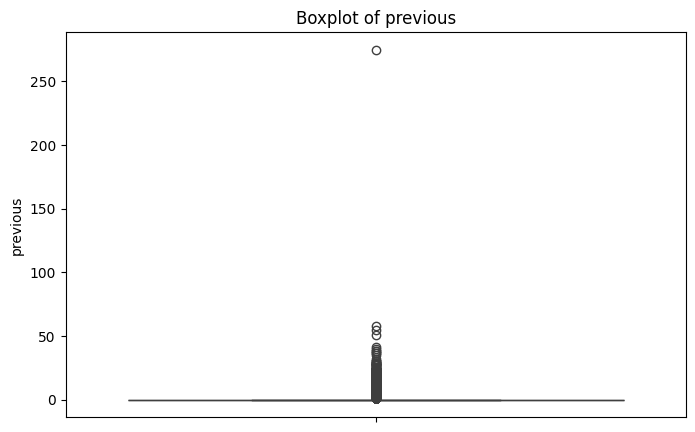

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

# Visualize Target Variable Distribution
sns.countplot(x='y', data=raw_data)
plt.title('Target Variable Distribution')
plt.show()

# Plot Histograms for Numerical Features
numerical_columns = raw_data.select_dtypes(include=['int64', 'float64']).columns
for col in numerical_columns:
    plt.figure(figsize=(8, 5))
    sns.histplot(raw_data[col], kde=True)
    plt.title(f"Histogram of {col}")
    plt.show()

# Boxplots for Outlier Detection
for col in numerical_columns:
    plt.figure(figsize=(8, 5))
    sns.boxplot(y=raw_data[col])
    plt.title(f"Boxplot of {col}")
    plt.show()


Data with handled outliers saved to handled_outliers_bank_data.csv


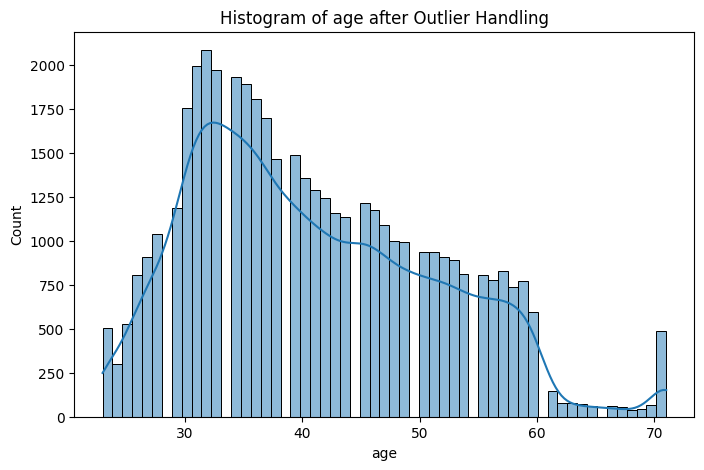

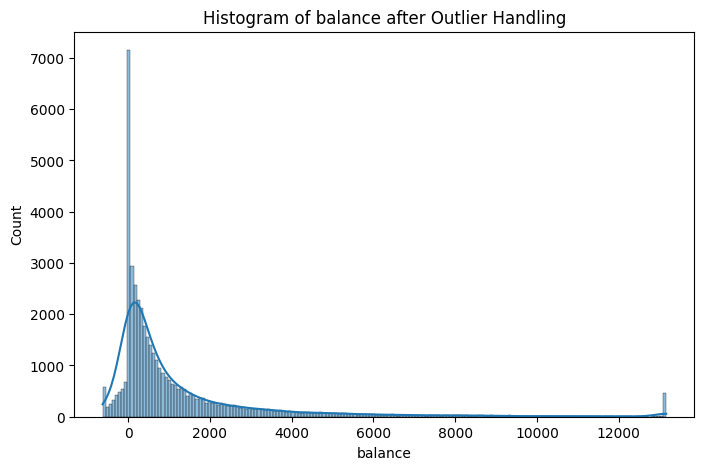

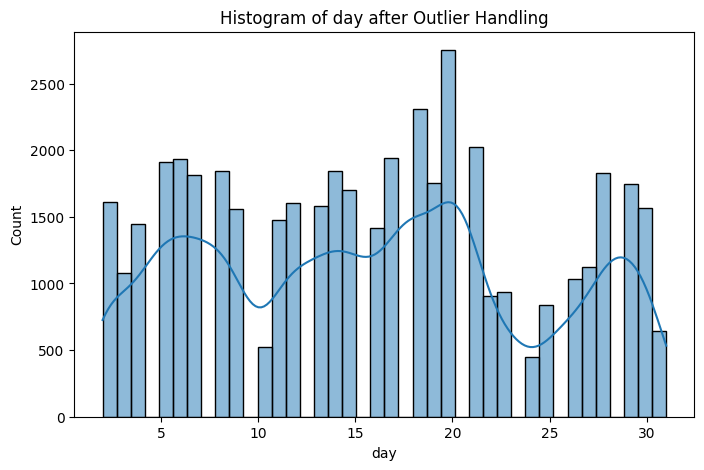

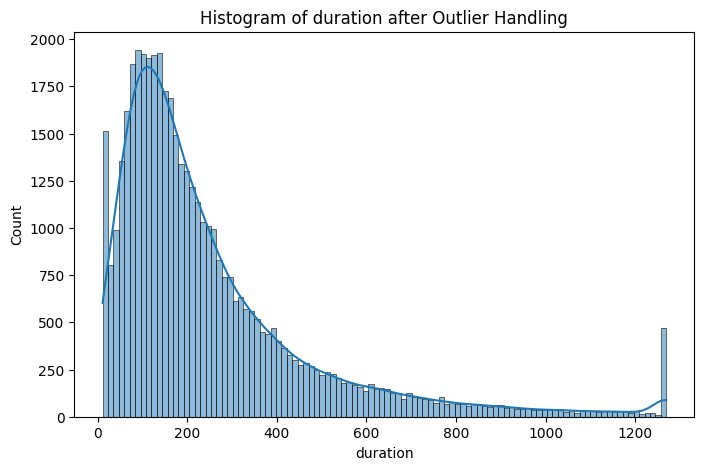

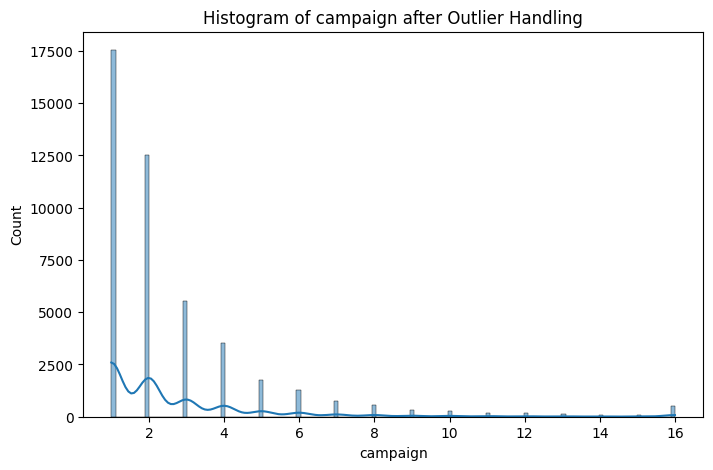

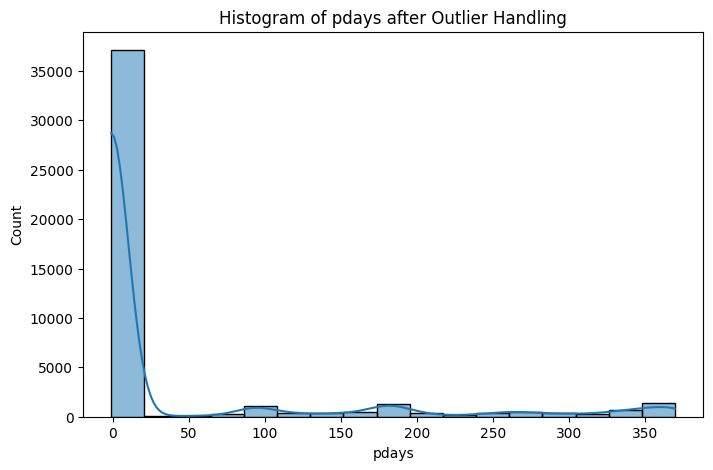

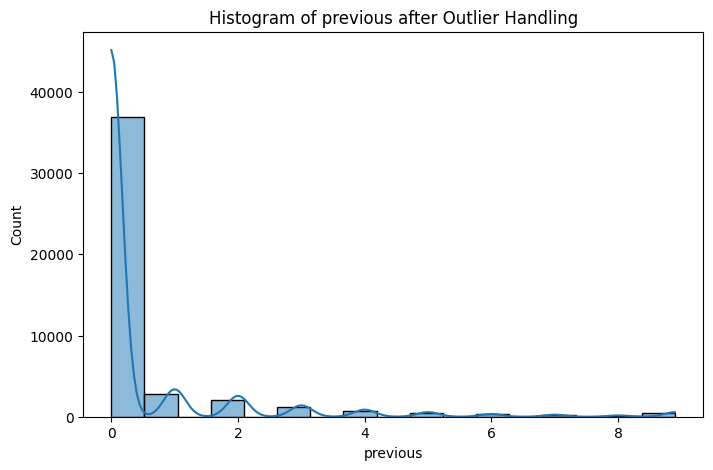

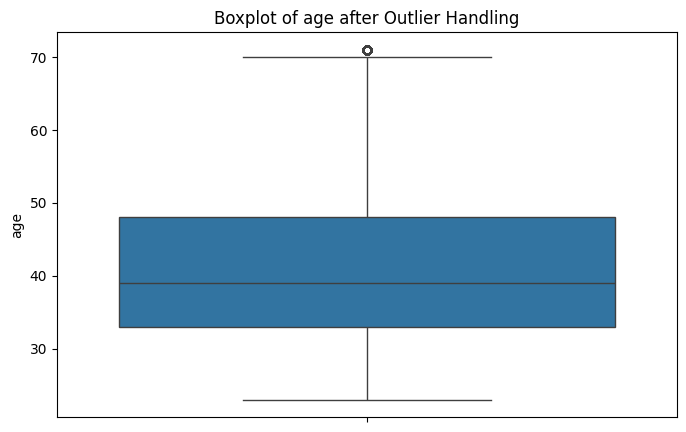

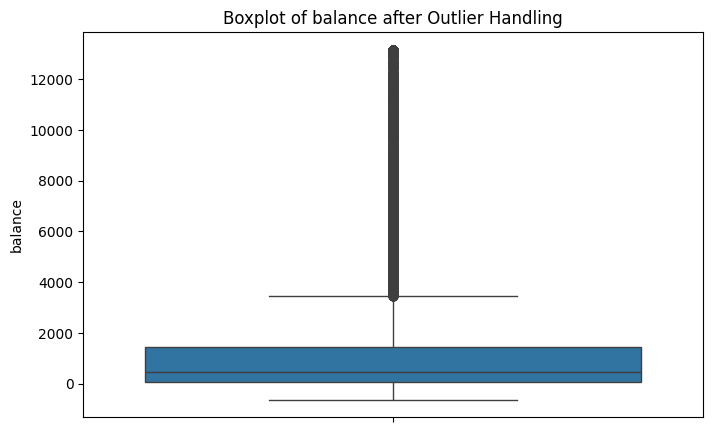

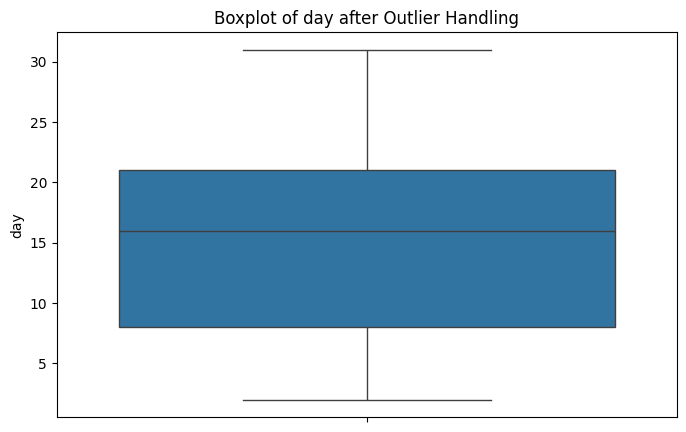

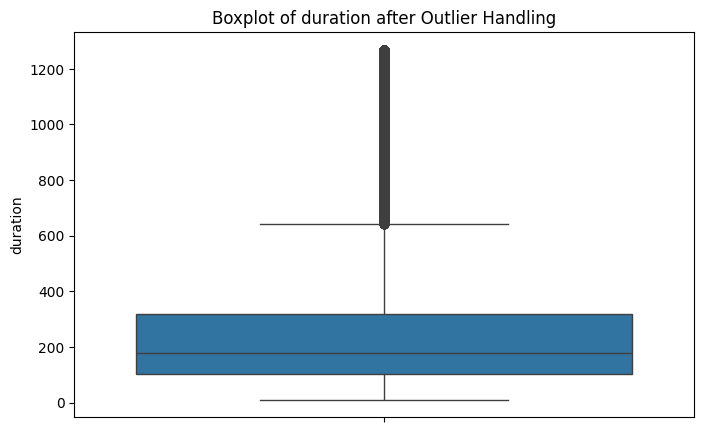

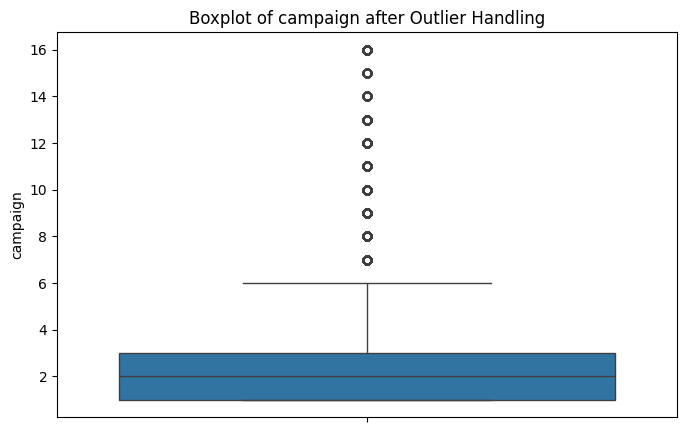

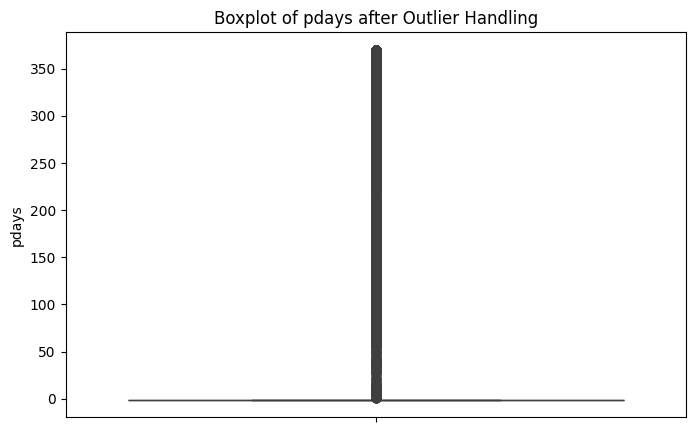

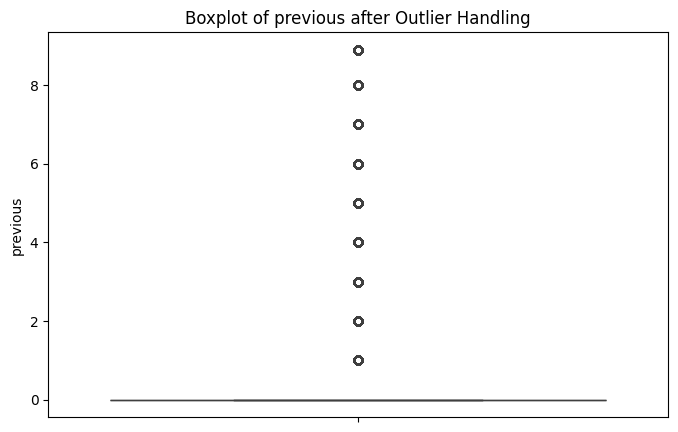

In [ ]:
# Outlier Handling: Capping
def cap_outliers(df, col):
    lower_bound = df[col].quantile(0.01)
    upper_bound = df[col].quantile(0.99)
    df[col] = df[col].apply(lambda x: lower_bound if x < lower_bound else (upper_bound if x > upper_bound else x))
    return df

for col in numerical_columns:
    raw_data = cap_outliers(raw_data, col)

# Save the data after outlier handling
output_file_path = 'handled_outliers_bank_data.csv'
raw_data.to_csv(output_file_path, index=False)
print(f"Data with handled outliers saved to {output_file_path}")

# Plot Histograms for Numerical Features after Outlier Handling
for col in numerical_columns:
    plt.figure(figsize=(8, 5))
    sns.histplot(raw_data[col], kde=True)
    plt.title(f"Histogram of {col} after Outlier Handling")
    plt.show()

# Boxplots for Outlier Detection after Outlier Handling
for col in numerical_columns:
    plt.figure(figsize=(8, 5))
    sns.boxplot(y=raw_data[col])
    plt.title(f"Boxplot of {col} after Outlier Handling")
    plt.show()

In [ ]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

# Identify Categorical and Numerical Features
categorical_columns = raw_data.select_dtypes(include=['object']).columns.difference(['y'])
numerical_columns = raw_data.select_dtypes(include=['int64', 'float64']).columns

# Preprocessing Pipeline
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numerical_columns),
        ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), categorical_columns)
    ]
)

# Prepare Features and Target
X = raw_data.drop('y', axis=1)
y = raw_data['y'].map({'yes': 1, 'no': 0})  # Convert target to binary


In [ ]:
from sklearn.model_selection import train_test_split

# Split into Training and Testing Sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)

print("Training Features Shape:", X_train.shape)
print("Testing Features Shape:", X_test.shape)


Training Features Shape: (36168, 16)
Testing Features Shape: (9043, 16)


In [ ]:
from imblearn.over_sampling import SMOTE
from collections import Counter

# Apply Preprocessing to Training Data
X_train_encoded = preprocessor.fit_transform(X_train)

# SMOTE
print("Class Distribution Before SMOTE:", Counter(y_train))
smote = SMOTE(random_state=42)
X_train_smote, y_train_smote = smote.fit_resample(X_train_encoded, y_train)
print("Class Distribution After SMOTE:", Counter(y_train_smote))


Class Distribution Before SMOTE: Counter({0: 31937, 1: 4231})


/usr/local/lib/python3.10/dist-packages/sklearn/base.py:474: FutureWarning: `BaseEstimator._validate_data` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation.validate_data` instead. This function becomes public and is part of the scikit-learn developer API.
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/utils/_tags.py:354: FutureWarning: The SMOTE or classes from which it inherits use `_get_tags` and `_more_tags`. Please define the `__sklearn_tags__` method, or inherit from `sklearn.base.BaseEstimator` and/or other appropriate mixins such as `sklearn.base.TransformerMixin`, `sklearn.base.ClassifierMixin`, `sklearn.base.RegressorMixin`, and `sklearn.base.OutlierMixin`. From scikit-learn 1.7, not defining `__sklearn_tags__` will raise an error.
  warnings.warn(


Class Distribution After SMOTE: Counter({0: 31937, 1: 31937})


In [ ]:
from imblearn.over_sampling import ADASYN

# ADASYN
print("Class Distribution Before ADASYN:", Counter(y_train))
adasyn = ADASYN(random_state=42)
X_train_adasyn, y_train_adasyn = adasyn.fit_resample(X_train_encoded, y_train)
print("Class Distribution After ADASYN:", Counter(y_train_adasyn))


Class Distribution Before ADASYN: Counter({0: 31937, 1: 4231})


/usr/local/lib/python3.10/dist-packages/sklearn/base.py:474: FutureWarning: `BaseEstimator._validate_data` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation.validate_data` instead. This function becomes public and is part of the scikit-learn developer API.
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/utils/_tags.py:354: FutureWarning: The ADASYN or classes from which it inherits use `_get_tags` and `_more_tags`. Please define the `__sklearn_tags__` method, or inherit from `sklearn.base.BaseEstimator` and/or other appropriate mixins such as `sklearn.base.TransformerMixin`, `sklearn.base.ClassifierMixin`, `sklearn.base.RegressorMixin`, and `sklearn.base.OutlierMixin`. From scikit-learn 1.7, not defining `__sklearn_tags__` will raise an error.
  warnings.warn(


Class Distribution After ADASYN: Counter({1: 32047, 0: 31937})


In [ ]:
from imblearn.combine import SMOTETomek

# SMOTE + Tomek
print("Class Distribution Before SMOTE + Tomek:", Counter(y_train))
smtom = SMOTETomek(random_state=42)
X_train_smtom, y_train_smtom = smtom.fit_resample(X_train_encoded, y_train)
print("Class Distribution After SMOTE + Tomek:", Counter(y_train_smtom))


Class Distribution Before SMOTE + Tomek: Counter({0: 31937, 1: 4231})


/usr/local/lib/python3.10/dist-packages/sklearn/base.py:474: FutureWarning: `BaseEstimator._validate_data` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation.validate_data` instead. This function becomes public and is part of the scikit-learn developer API.
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/utils/_tags.py:354: FutureWarning: The SMOTETomek or classes from which it inherits use `_get_tags` and `_more_tags`. Please define the `__sklearn_tags__` method, or inherit from `sklearn.base.BaseEstimator` and/or other appropriate mixins such as `sklearn.base.TransformerMixin`, `sklearn.base.ClassifierMixin`, `sklearn.base.RegressorMixin`, and `sklearn.base.OutlierMixin`. From scikit-learn 1.7, not defining `__sklearn_tags__` will raise an error.
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/base.py:474: FutureWarning: `BaseEstimator._validate_data` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.vali

Class Distribution After SMOTE + Tomek: Counter({0: 31092, 1: 31092})


In [ ]:
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, roc_auc_score

# Define the parameter grid for GridSearchCV
param_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth': [5, 10, None],
    'min_samples_split': [5, 10],
    'min_samples_leaf': [1, 2],
    'class_weight': ['balanced']
}

# Initialize Random Forest
rf = RandomForestClassifier(random_state=42)

# Initialize GridSearchCV
grid_search = GridSearchCV(
    estimator=rf,
    param_grid=param_grid,
    scoring='roc_auc',
    cv=3,
    verbose=2,
    n_jobs=-1
)

# Fit GridSearchCV on the resampled training data
grid_search.fit(X_train_smote, y_train_smote)  # Use SMOTE-resampled data
best_rf = grid_search.best_estimator_

# Print the best parameters
print("Best Parameters:", grid_search.best_params_)

# Train the best model on resampled training data
best_rf.fit(X_train_smote, y_train_smote)

# Apply preprocessing to the test data
X_test_encoded = preprocessor.transform(X_test)

# Evaluate the best model on the original test set
y_pred = best_rf.predict(X_test_encoded)  # Predict labels
y_pred_proba = best_rf.predict_proba(X_test_encoded)[:, 1]  # Predict probabilities

# Print classification metrics
print("Random Forest Results:")
print(classification_report(y_test, y_pred))
print(f"ROC-AUC Score: {roc_auc_score(y_test, y_pred_proba)}")


Fitting 3 folds for each of 36 candidates, totalling 108 fits
Best Parameters: {'class_weight': 'balanced', 'max_depth': None, 'min_samples_leaf': 1, 'min_samples_split': 5, 'n_estimators': 300}
Random Forest Results:
              precision    recall  f1-score   support

           0       0.94      0.95      0.95      7985
           1       0.59      0.57      0.58      1058

    accuracy                           0.90      9043
   macro avg       0.77      0.76      0.76      9043
weighted avg       0.90      0.90      0.90      9043

ROC-AUC Score: 0.9298213924264896


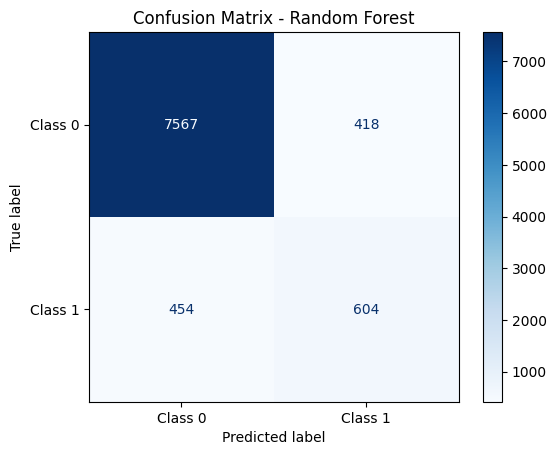

Random Forest Confusion Matrix:
[[7567  418]
 [ 454  604]]


In [ ]:
from sklearn.metrics import ConfusionMatrixDisplay, confusion_matrix

# Generate the confusion matrix
rf_confusion_matrix = confusion_matrix(y_test, y_pred)

# Plot the confusion matrix
ConfusionMatrixDisplay(rf_confusion_matrix, display_labels=["Class 0", "Class 1"]).plot(cmap="Blues")
plt.title("Confusion Matrix - Random Forest")
plt.show()

# Print the confusion matrix values
print("Random Forest Confusion Matrix:")
print(rf_confusion_matrix)


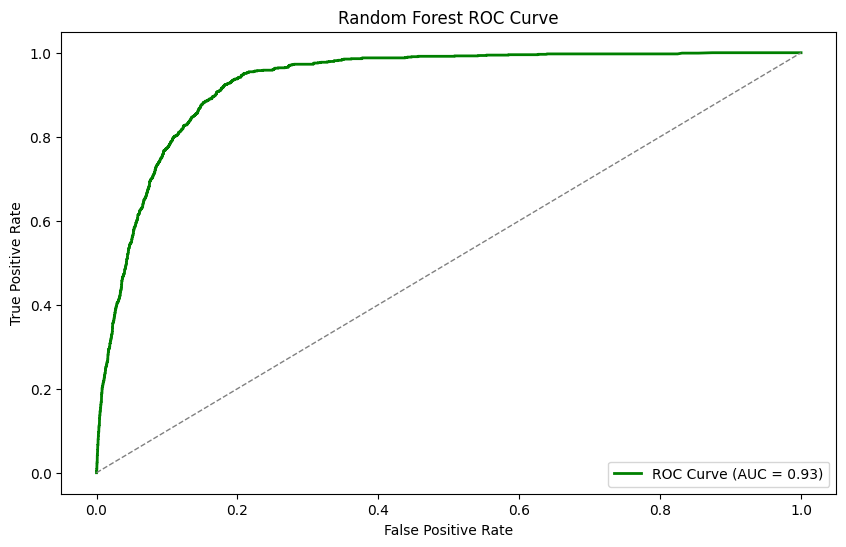

In [ ]:
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

# Plot ROC Curve for Random Forest
fpr, tpr, thresholds = roc_curve(y_test, y_pred_proba)  # Use predicted probabilities
roc_auc = auc(fpr, tpr)  # Calculate AUC score

plt.figure(figsize=(10, 6))
plt.plot(fpr, tpr, color='green', lw=2, label=f'ROC Curve (AUC = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='gray', linestyle='--', lw=1)  # Diagonal line for random guess
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Random Forest ROC Curve')
plt.legend(loc='lower right')
plt.show()


In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Define the neural network model
nn_model = Sequential([
    Dense(32, activation='relu', input_shape=(X_train_encoded.shape[1],)),
    Dropout(0.2),  # Dropout layer to prevent overfitting
    Dense(16, activation='relu'),
    Dropout(0.2),  # Dropout layer to prevent overfitting
    Dense(1, activation='sigmoid')
])

# Compile the model
nn_model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

# Early stopping to avoid overfitting
early_stopping = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)

# Train the model
history = nn_model.fit(X_train_encoded, y_train_smote, epochs=20, batch_size=32, validation_split=0.2,
                       verbose=1, callbacks=[early_stopping])

# Calculate average training accuracy
average_train_accuracy = sum(history.history['accuracy']) / len(history.history['accuracy'])
print("\nAverage Training Accuracy:", average_train_accuracy)

# Make predictions
y_pred_nn_proba = nn_model.predict(X_test_encoded)  # Predict probabilities
y_pred_nn = (y_pred_nn_proba > 0.5).astype(int)     # Convert probabilities to binary predictions

# Evaluate the model
print("\nNeural Network Results:")
print("Accuracy:", accuracy_score(y_test, y_pred_nn))
print("Classification Report:\n", classification_report(y_test, y_pred_nn))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred_nn))


/usr/local/lib/python3.10/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/20
905/905 ━━━━━━━━━━━━━━━━━━━━ 14s 9ms/step - accuracy: 0.8493 - loss: 0.3421 - val_accuracy: 0.9030 - val_loss: 0.2183
Epoch 2/20
905/905 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - accuracy: 0.8954 - loss: 0.2352 - val_accuracy: 0.9057 - val_loss: 0.2121
Epoch 3/20
905/905 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.8996 - loss: 0.2254 - val_accuracy: 0.9053 - val_loss: 0.2104
Epoch 4/20
905/905 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.9022 - loss: 0.2220 - val_accuracy: 0.9038 - val_loss: 0.2085
Epoch 5/20
905/905 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.9054 - loss: 0.2136 - val_accuracy: 0.9077 - val_loss: 0.2060
Epoch 6/20
905/905 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.9049 - loss: 0.2109 - val_accuracy: 0.9066 - val_loss: 0.2045
Epoch 7/20
905/905 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.9035 - loss: 0.2112 - val_accuracy: 0.9099 - val_loss: 0.2020
Epoch 8/20
905/905 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.9075 - loss: 0.2046 - val_accuracy: 0

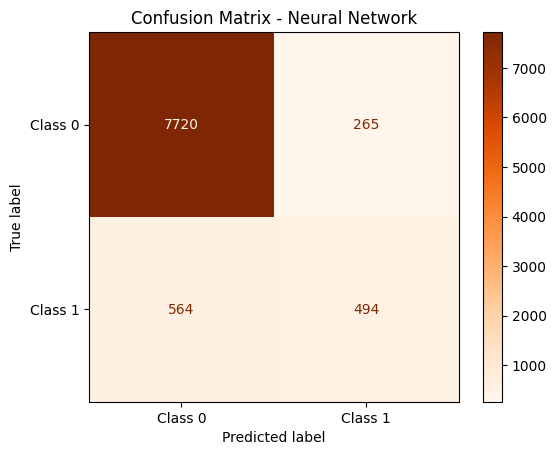

Neural Network Confusion Matrix:
[[7720  265]
 [ 564  494]]


In [ ]:
# Generate the confusion matrix
nn_confusion_matrix = confusion_matrix(y_test, y_pred_nn)

# Plot the confusion matrix
ConfusionMatrixDisplay(nn_confusion_matrix, display_labels=["Class 0", "Class 1"]).plot(cmap="Oranges")
plt.title("Confusion Matrix - Neural Network")
plt.show()

# Print the confusion matrix values
print("Neural Network Confusion Matrix:")
print(nn_confusion_matrix)


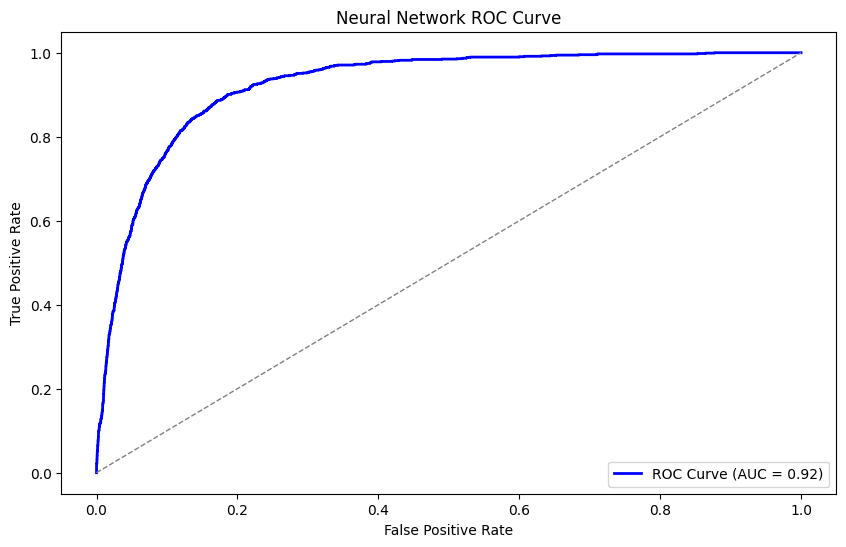

In [ ]:
# Plot ROC Curve for Neural Network
fpr, tpr, thresholds = roc_curve(y_test, y_pred_nn_proba)  # Use predicted probabilities
roc_auc = auc(fpr, tpr)  # Calculate AUC score

plt.figure(figsize=(10, 6))
plt.plot(fpr, tpr, color='blue', lw=2, label=f'ROC Curve (AUC = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='gray', linestyle='--', lw=1)  # Diagonal line for random guess
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Neural Network ROC Curve')
plt.legend(loc='lower right')
plt.show()


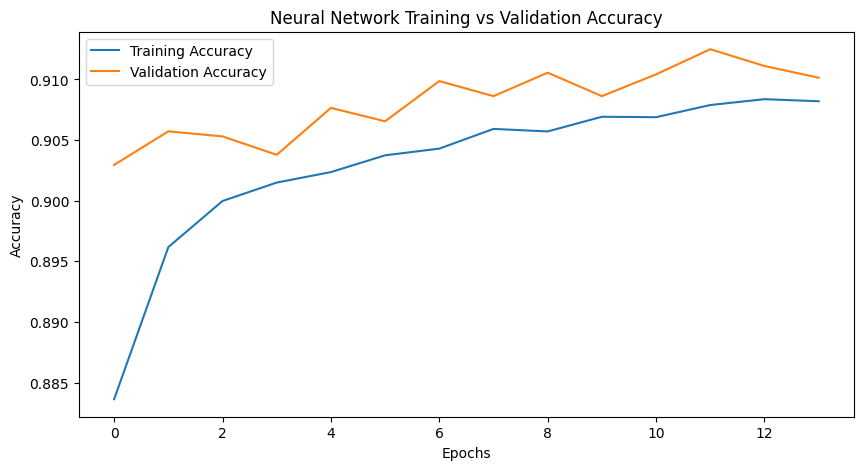

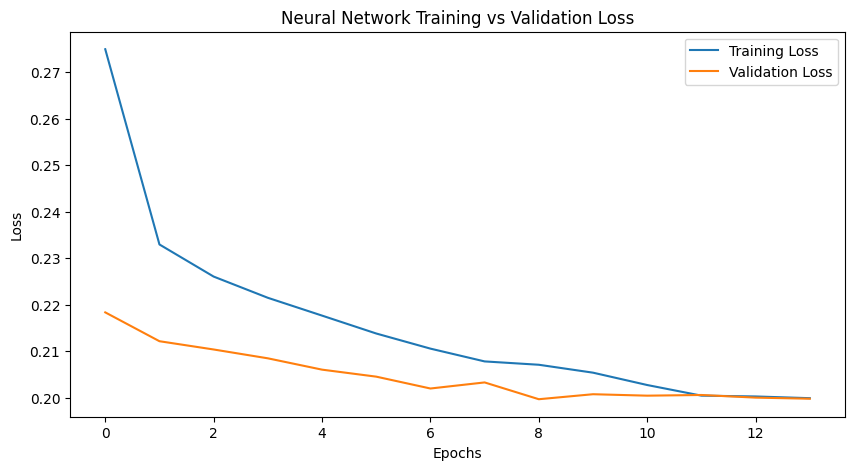

In [ ]:
# Plot Training Accuracy and Validation Accuracy
plt.figure(figsize=(10, 5))
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Neural Network Training vs Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

# Plot Training Loss and Validation Loss
plt.figure(figsize=(10, 5))
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Neural Network Training vs Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()


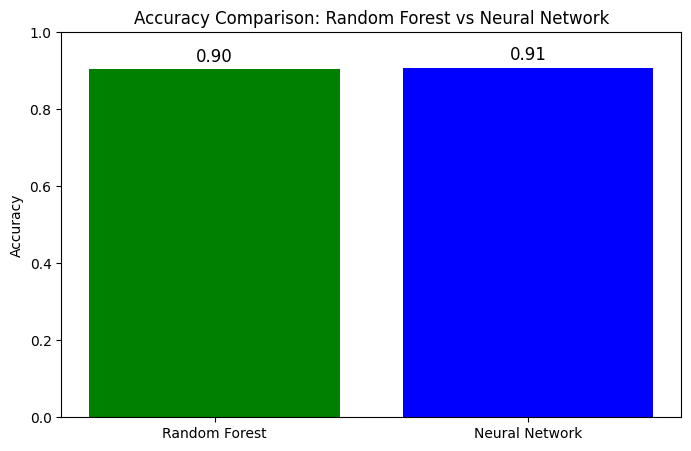

In [ ]:
# Accuracy of Random Forest and Neural Network
rf_accuracy = accuracy_score(y_test, y_pred)  # From Random Forest
nn_accuracy = accuracy_score(y_test, y_pred_nn)  # From Neural Network

# Bar Plot for Accuracy Comparison
models = ['Random Forest', 'Neural Network']
accuracies = [rf_accuracy, nn_accuracy]

plt.figure(figsize=(8, 5))
plt.bar(models, accuracies, color=['green', 'blue'])
plt.title('Accuracy Comparison: Random Forest vs Neural Network')
plt.ylabel('Accuracy')
plt.ylim(0, 1)  # Set y-axis range for clarity
for i, acc in enumerate(accuracies):
    plt.text(i, acc + 0.02, f"{acc:.2f}", ha='center', fontsize=12)  # Annotate bars
plt.show()


In [ ]:
# Random Forest Without Class Balancing
rf_unbalanced = RandomForestClassifier(n_estimators=300, random_state=42, class_weight=None)
# Apply preprocessing to the training data before fitting the model
X_train_encoded = preprocessor.fit_transform(X_train) # Encode X_train
rf_unbalanced.fit(X_train_encoded, y_train) # Fit the model with encoded data
y_pred_unbalanced = rf_unbalanced.predict(X_test_encoded)
print("Random Forest Without Class Balancing:")
print(classification_report(y_test, y_pred_unbalanced))

# Random Forest With Class Balancing
rf_balanced = RandomForestClassifier(n_estimators=300, random_state=42, class_weight='balanced')
rf_balanced.fit(X_train_smote, y_train_smote)
y_pred_balanced = rf_balanced.predict(X_test_encoded)
print("Random Forest With Class Balancing:")
print(classification_report(y_test, y_pred_balanced))


Random Forest Without Class Balancing:
              precision    recall  f1-score   support

           0       0.92      0.97      0.95      7985
           1       0.67      0.40      0.50      1058

    accuracy                           0.91      9043
   macro avg       0.80      0.69      0.73      9043
weighted avg       0.90      0.91      0.90      9043

Random Forest With Class Balancing:
              precision    recall  f1-score   support

           0       0.94      0.95      0.94      7985
           1       0.58      0.55      0.56      1058

    accuracy                           0.90      9043
   macro avg       0.76      0.75      0.75      9043
weighted avg       0.90      0.90      0.90      9043



In [ ]:
# Train Random Forest on Raw Features (No Scaling) BUT WITH ONE HOT ENCODING
rf_raw = RandomForestClassifier(n_estimators=300, random_state=42)

# 1. Create a ColumnTransformer to OneHotEncode categorical columns
categorical_columns = X_train.select_dtypes(include=['object']).columns
preprocessor = ColumnTransformer(
    transformers=[
        ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), categorical_columns)
    ],
    remainder='passthrough' # Passthrough numerical features
)

# 2. Fit and transform on training data
X_train_encoded = preprocessor.fit_transform(X_train)

# 3. Transform test data using the same preprocessor
X_test_encoded = preprocessor.transform(X_test)

# 4. Fit the RandomForestClassifier with the encoded data
rf_raw.fit(X_train_encoded, y_train)

y_pred_raw = rf_raw.predict(X_test_encoded)
print("Random Forest Without Normalization:")
print(classification_report(y_test, y_pred_raw))

Random Forest Without Normalization:
              precision    recall  f1-score   support

           0       0.93      0.97      0.95      7985
           1       0.68      0.41      0.51      1058

    accuracy                           0.91      9043
   macro avg       0.80      0.69      0.73      9043
weighted avg       0.90      0.91      0.90      9043



In [ ]:
from sklearn.metrics import f1_score # Import f1_score

print("Best Parameters from GridSearchCV:", grid_search.best_params_)
print("F1 Score Before Tuning:", f1_score(y_test, y_pred_unbalanced))
print("F1 Score After Tuning:", f1_score(y_test, y_pred))

Best Parameters from GridSearchCV: {'class_weight': 'balanced', 'max_depth': None, 'min_samples_leaf': 1, 'min_samples_split': 5, 'n_estimators': 300}
F1 Score Before Tuning: 0.5026674570243035
F1 Score After Tuning: 0.5807692307692308


In [ ]:
# Train NN Without Balancing
nn_model_unbalanced = Sequential([
    Dense(32, activation='relu', input_shape=(X_train_encoded.shape[1],)),
    Dense(16, activation='relu'),
    Dense(1, activation='sigmoid')
])
nn_model_unbalanced.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
history_unbalanced = nn_model_unbalanced.fit(X_train_encoded, y_train, epochs=20, batch_size=32, verbose=1)
y_pred_nn_unbalanced = (nn_model_unbalanced.predict(X_test_encoded) > 0.5).astype(int)
print("NN Without Balancing:")
print(classification_report(y_test, y_pred_nn_unbalanced))


Epoch 1/20


/usr/local/lib/python3.10/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


1131/1131 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.7885 - loss: 4.1617
Epoch 2/20
1131/1131 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.8548 - loss: 0.8674
Epoch 3/20
1131/1131 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.8726 - loss: 0.4701
Epoch 4/20
1131/1131 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.8747 - loss: 0.4602
Epoch 5/20
1131/1131 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.8803 - loss: 0.4267
Epoch 6/20
1131/1131 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.8838 - loss: 0.4136
Epoch 7/20
1131/1131 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.8876 - loss: 0.3386
Epoch 8/20
1131/1131 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.8862 - loss: 0.3542
Epoch 9/20
1131/1131 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.8900 - loss: 0.2907
Epoch 10/20
1131/1131 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.8878 - loss: 0.3185
Epoch 11/20
1131/1131 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.8918 - loss: 0.2894
Epoch 12/20
1131/1131 ━━━━━━━━━━━━━━━━━━━

In [ ]:
# Train NN Without Normalization
nn_model_raw = Sequential([
    Dense(32, activation='relu', input_shape=(X_train_encoded.shape[1],)), # Use X_train_encoded shape
    Dense(16, activation='relu'),
    Dense(1, activation='sigmoid')
])
nn_model_raw.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
history_raw = nn_model_raw.fit(X_train_encoded, y_train, epochs=20, batch_size=32, verbose=1) # Use X_train_encoded
y_pred_nn_raw = (nn_model_raw.predict(X_test_encoded) > 0.5).astype(int) # Use X_test_encoded
print("NN Without Normalization:")
print(classification_report(y_test, y_pred_nn_raw))

/usr/local/lib/python3.10/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/20
1131/1131 ━━━━━━━━━━━━━━━━━━━━ 7s 3ms/step - accuracy: 0.8392 - loss: 1.9848
Epoch 2/20
1131/1131 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.8707 - loss: 0.5575
Epoch 3/20
1131/1131 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.8692 - loss: 0.5453
Epoch 4/20
1131/1131 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.8752 - loss: 0.5555
Epoch 5/20
1131/1131 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.8766 - loss: 0.5080
Epoch 6/20
1131/1131 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.8714 - loss: 0.5521
Epoch 7/20
1131/1131 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.8865 - loss: 0.3753
Epoch 8/20
1131/1131 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.8854 - loss: 0.3772
Epoch 9/20
1131/1131 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.8899 - loss: 0.3446
Epoch 10/20
1131/1131 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.8876 - loss: 0.3748
Epoch 11/20
1131/1131 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.8887 - loss: 0.3353
Epoch 12/20
1131/1131 ━━━━━━━━

In [ ]:
# Train NN with Additional Layers
nn_model_deep = Sequential([
    Dense(64, activation='relu', input_shape=(X_train_encoded.shape[1],)),
    Dense(32, activation='relu'),
    Dense(16, activation='relu'),
    Dense(8, activation='relu'),
    Dense(1, activation='sigmoid')
])
nn_model_deep.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

# Use X_train_smote (oversampled data) for training
history_deep = nn_model_deep.fit(X_train_smote, y_train_smote, epochs=20, batch_size=32, verbose=1)

y_pred_nn_deep = (nn_model_deep.predict(X_test_encoded) > 0.5).astype(int)
print("NN with Additional Layers:")
print(classification_report(y_test, y_pred_nn_deep))

Epoch 1/20


/usr/local/lib/python3.10/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


1997/1997 ━━━━━━━━━━━━━━━━━━━━ 10s 3ms/step - accuracy: 0.8195 - loss: 0.4021
Epoch 2/20
1997/1997 ━━━━━━━━━━━━━━━━━━━━ 11s 3ms/step - accuracy: 0.8892 - loss: 0.2774
Epoch 3/20
1997/1997 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.9007 - loss: 0.2534
Epoch 4/20
1997/1997 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.9069 - loss: 0.2400
Epoch 5/20
1997/1997 ━━━━━━━━━━━━━━━━━━━━ 14s 5ms/step - accuracy: 0.9147 - loss: 0.2208
Epoch 6/20
1997/1997 ━━━━━━━━━━━━━━━━━━━━ 11s 5ms/step - accuracy: 0.9195 - loss: 0.2110
Epoch 7/20
1997/1997 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9225 - loss: 0.2049
Epoch 8/20
1997/1997 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.9273 - loss: 0.1914
Epoch 9/20
1997/1997 ━━━━━━━━━━━━━━━━━━━━ 8s 2ms/step - accuracy: 0.9298 - loss: 0.1873
Epoch 10/20
1997/1997 ━━━━━━━━━━━━━━━━━━━━ 7s 3ms/step - accuracy: 0.9320 - loss: 0.1823
Epoch 11/20
1997/1997 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.9359 - loss: 0.1750
Epoch 12/20
1997/1997 ━━━━━━━━━━━━━━━

/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [ ]:
from imblearn.over_sampling import RandomOverSampler

# Apply oversampling to the test set
ros = RandomOverSampler(random_state=42)
X_test_balanced, y_test_balanced = ros.fit_resample(X_test_encoded, y_test)

# Evaluate the models on the balanced test set
y_pred_rf_balanced = best_rf.predict(X_test_balanced)
y_pred_nn_balanced = (nn_model.predict(X_test_balanced) > 0.5).astype(int)

# Print classification metrics for Random Forest
print("Random Forest on Balanced Test Set:")
print(classification_report(y_test_balanced, y_pred_rf_balanced))

# Print classification metrics for Neural Network
print("Neural Network on Balanced Test Set:")
print(classification_report(y_test_balanced, y_pred_nn_balanced))


/usr/local/lib/python3.10/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/base.py:484: FutureWarning: `BaseEstimator._check_n_features` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation._check_n_features` instead.
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/base.py:493: FutureWarning: `BaseEstimator._check_feature_names` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation._check_feature_names` instead.
  warnings.warn(


500/500 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step
Random Forest on Balanced Test Set:
              precision    recall  f1-score   support

           0       0.56      0.80      0.66      7985
           1       0.65      0.37      0.48      7985

    accuracy                           0.59     15970
   macro avg       0.61      0.59      0.57     15970
weighted avg       0.61      0.59      0.57     15970

Neural Network on Balanced Test Set:
              precision    recall  f1-score   support

           0       0.49      0.35      0.41      7985
           1       0.49      0.63      0.56      7985

    accuracy                           0.49     15970
   macro avg       0.49      0.49      0.48     15970
weighted avg       0.49      0.49      0.48     15970

